In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

Dataset:

Dua, D. and Graff, C. (2019). UCI Machine Learning Repository [http://archive.ics.uci.edu/ml]. Irvine, CA: University of California, School of
Information and Computer Science.

Source: Data Source :http://data.seoul.go.kr/ SOUTH KOREA PUBLIC HOLIDAYS. URL: publicholidays.go.kr

In [ ]:
df = pd.read_csv("SeoulBikeData.csv", encoding="unicode_escape")

df.columns = [
    "date", "bike_count", "hour", "temp", "humidity", "wind",
    "visibility", "dew_pt_temp", "radiation", "rainfall",
    "snowfall", "seasons", "holiday", "functional"
]

df["functional"] = (df["functional"] == "Yes").astype(int)
df = df[df["hour"] == 12]
df = df.drop(columns=["date", "hour"])

# Encode BEFORE get_xy
df = pd.get_dummies(df, columns=["seasons", "holiday"])
df = df.astype({col: int for col in df.select_dtypes(bool).columns})

In [ ]:
df_shuffled = df.sample(frac=1).reset_index(drop=True)
train = df_shuffled.iloc[:int(0.6 * len(df_shuffled))]
val   = df_shuffled.iloc[int(0.6 * len(df_shuffled)):int(0.8 * len(df_shuffled))]
test  = df_shuffled.iloc[int(0.8 * len(df_shuffled)):]

In [ ]:
print(df.columns.tolist())

In [ ]:
df.head()

In [ ]:
for label in df.columns[1:]:
    plt.scatter(df[label],df["bike_count"])
    plt.title(label)
    plt.ylabel("Bike Count a Noon")
    plt.xlabel(label)
    plt.show()

In [ ]:
df = df.drop(["wind","visibility","functional"], axis=1)

In [ ]:
df.head()

Train/valid/test dataset

In [ ]:
df_shuffled = df.sample(frac=1).reset_index(drop=True)
n = len(df_shuffled)
train = df_shuffled.iloc[:int(0.6 * n)]
val   = df_shuffled.iloc[int(0.6 * n):int(0.8 * n)]
test  = df_shuffled.iloc[int(0.8 * n):]

In [ ]:
def get_xy(dataframe, y_label, x_label=None):
    dataframe = copy.deepcopy(dataframe)
    if x_label is None:
        x = dataframe[[c for c in dataframe.columns if c != y_label]].values
    else:
        if len(x_label) == 1:
            x = dataframe[x_label[0]].values.reshape(-1, 1)
        else:
            x = dataframe[x_label].values
    y = dataframe[y_label].values.reshape(-1, 1)
    data = np.hstack((x, y))
    return data, x, y

In [ ]:
_, x_train_temp, y_train_temp = get_xy(train, "bike_count", x_label=["temp"])
_, x_val_temp, y_val_temp = get_xy(val, "bike_count", x_label=["temp"])
_, x_test_temp, y_test_temp = get_xy(test, "bike_count", x_label=["temp"])

In [ ]:
x_train_temp = x_train_temp.astype(np.float32)
x_val_temp   = x_val_temp.astype(np.float32)
x_test_temp  = x_test_temp.astype(np.float32)
y_train_temp = y_train_temp.astype(np.float32)
y_val_temp   = y_val_temp.astype(np.float32)
y_test_temp  = y_test_temp.astype(np.float32)

In [ ]:
temp_reg = LinearRegression()
temp_reg.fit(x_train_temp, y_train_temp)

In [ ]:
temp_reg.score(x_test_temp, y_test_temp)

In [ ]:
plt.scatter(x_train_temp, y_train_temp, label="Data",color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_reg.predict(np.array(x).reshape(-1, 1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()

Multiple Linear Regression

In [ ]:
df_shuffled = df.sample(frac=1).reset_index(drop=True)

train = df_shuffled.iloc[:int(0.6 * len(df_shuffled))]
val   = df_shuffled.iloc[int(0.6 * len(df_shuffled)):int(0.8 * len(df_shuffled))]
test  = df_shuffled.iloc[int(0.8 * len(df_shuffled)):]

_, X_train_all, y_train_all = get_xy(train, "bike_count", x_label=df.columns[1:].tolist())
_, X_val_all,   y_val_all   = get_xy(val,   "bike_count", x_label=df.columns[1:].tolist())
_, X_test_all,  y_test_all  = get_xy(test,  "bike_count", x_label=df.columns[1:].tolist())

In [ ]:
all_reg = LinearRegression()
all_reg.fit(X_train_all, y_train_all)

In [62]:
all_reg.score(X_test_all, y_test_all)

0.622065145270492

In [65]:
y_pred_lr = all_reg.predict(X_test_all)

Regression with Neural Net

In [20]:
temp_normalizer = tf.keras.layers.Normalization(axis=None)
temp_normalizer.adapt(x_train_temp.reshape(-1))

In [31]:
temp_nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(1,)),
    Dense(32, activation='relu'),
    Dense(1)
])

c:\Users\AMCS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
temp_nn_model.compile(optimizer='adam', loss='mse')

In [33]:
history = temp_nn_model.fit(
    x_train_temp.reshape(-1, 1), y_train_temp,
    verbose=0,
    epochs=1000,
    validation_data=(x_val_temp.reshape(-1, 1), y_val_temp)
)

In [35]:
def plot_loss(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

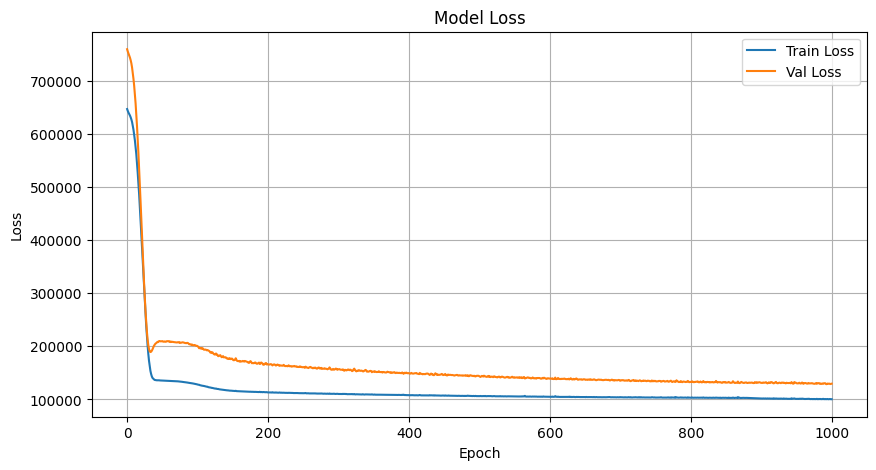

In [36]:
plot_loss(history)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


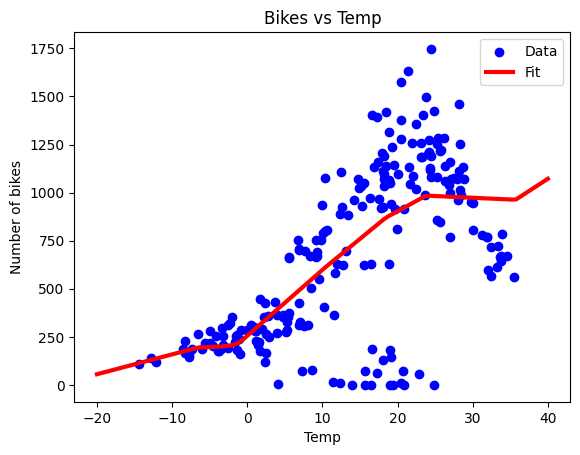

In [37]:
plt.scatter(x_train_temp, y_train_temp, label="Data",color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, temp_nn_model.predict(np.array(x).reshape(-1, 1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()

Neural Net

In [45]:
temp_normalizer = tf.keras.layers.Normalization(input_shape=(1,), axis=None)
temp_normalizer.adapt(x_train_temp.reshape(-1, 1))

nn_model = tf.keras.Sequential([
    temp_normalizer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

c:\Users\AMCS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [46]:
history = nn_model.fit(
    x_train_temp, y_train_temp,
    validation_data=(x_val_temp, y_val_temp),
    verbose=0, epochs=100
)

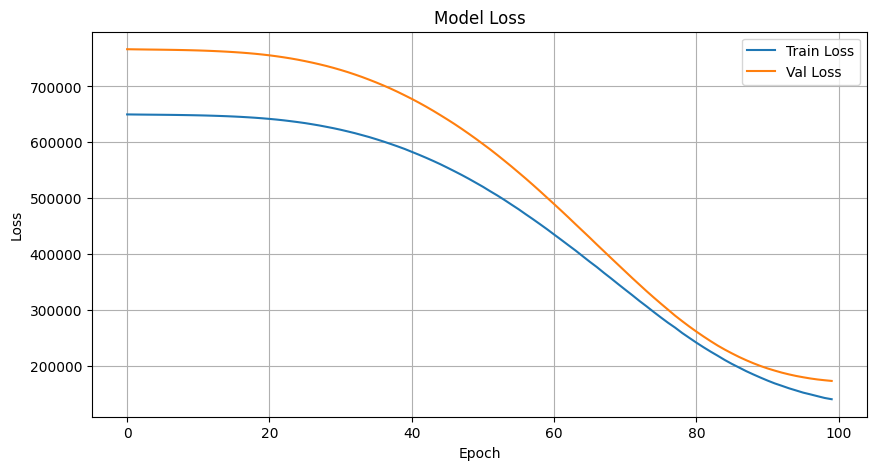

In [47]:
plot_loss(history)

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000019C09192980> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


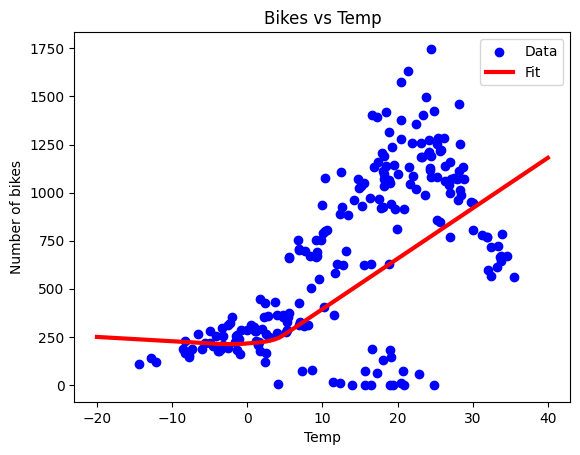

In [48]:
plt.scatter(x_train_temp, y_train_temp, label="Data",color="blue")
x = tf.linspace(-20, 40, 100)
plt.plot(x, nn_model.predict(np.array(x).reshape(-1, 1)), label="Fit", color="red", linewidth=3)
plt.legend()
plt.title("Bikes vs Temp")
plt.ylabel("Number of bikes")
plt.xlabel("Temp")
plt.show()

In [57]:
all_normalizer = tf.keras.layers.Normalization(axis=-1)
all_normalizer.adapt(X_train_all)

In [59]:
nn_model = tf.keras.Sequential([
    all_normalizer,
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error'
)

In [60]:
history = nn_model.fit(
    X_train_all, y_train_all,
    verbose=0,
    epochs=1000,
    validation_data=(X_val_all, y_val_all)
)

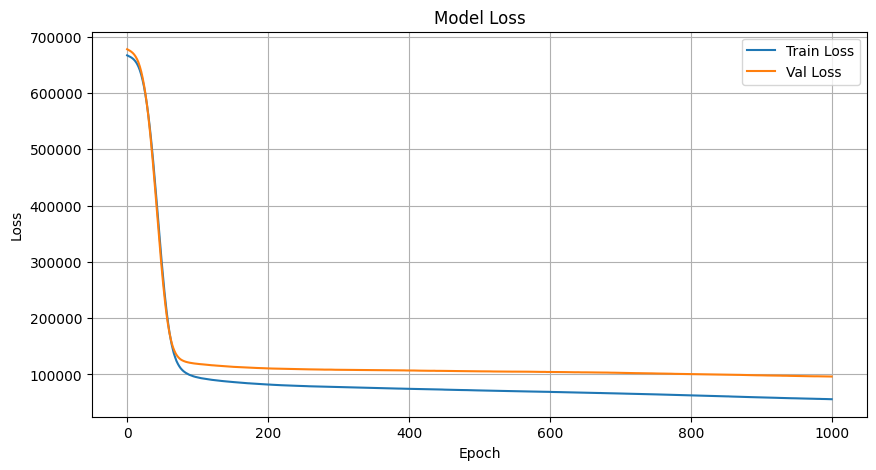

In [61]:
plot_loss(history)

Calculate the MSE for both Linear reg and nn

In [66]:
y_pred_lr = all_reg.predict(X_test_all)
y_pred_nn = nn_model.predict(X_test_all)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


In [67]:
def MSE(y_pred, y_real):
    return (np.square(y_pred - y_real)).mean()

In [68]:
MSE(y_pred_lr, y_test_all)

np.float64(76175.66905517437)

In [69]:
MSE(y_pred_nn, y_test_all)

np.float64(47633.696210376016)

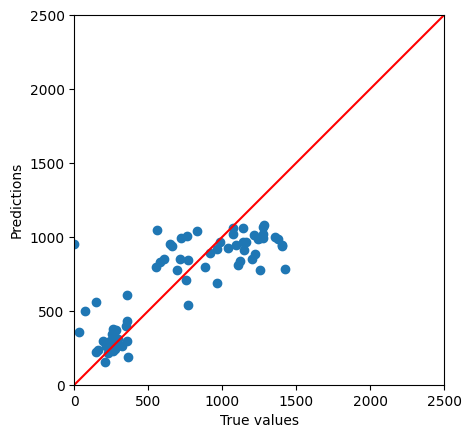

In [71]:
ax = plt.axes(aspect="equal")
plt.scatter(y_test_all, y_pred_lr, label="Lin Reg Preds")
plt.xlabel("True values")
plt.ylabel("Predictions")
lims = [0,2500]
plt.xlim(lims)
plt.ylim(lims)
_= plt.plot(lims,lims, c="red")